# Full 18 Experiments
## 6 Datasets × 3 Models (wav2vec 2.0, HuBERT, Whisper)

**Project:** Linguistic-Agnostic SER: A Probing Approach to Acoustic Emotion Encoding

CSCI 535 - Multimodal Probabilistic Learning of Human Communication

**Author:** Minoo Ahmadi

This notebook executes practically all 18 comprehensive experiments crossing 3 variants of speech architectures against 6 separate emotion datasets (with different languages).

**Method:** We extract hidden states from each layer of these massive transformers and apply linear probes. This mass scale validates whether emotional states are purely acoustic (linguistic-agnostic) across different architectures.

**Datasets:** RAVDESS, EmoDB, IEMOCAP, SAVEE, AESDD, MESD

**Models:** wav2vec 2.0 Base, HuBERT Base, Whisper

In [ ]:
!pip install -q torch transformers librosa scikit-learn numpy pandas matplotlib seaborn tqdm datasets soundfile kaggle

import torch
print(f'PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch: 2.10.0+cu128, CUDA: True
GPU: NVIDIA A100-SXM4-40GB


In [ ]:
import os, re, json, glob, gc
import numpy as np
import pandas as pd
import torch
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from transformers import (
    Wav2Vec2Model, Wav2Vec2Processor,
    HubertModel,
    WhisperModel, WhisperFeatureExtractor
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

print('All imports loaded!')

All imports loaded!


In [ ]:
import os, json
os.environ['KAGGLE_USERNAME'] = 'minooahm'
os.environ['KAGGLE_KEY'] = 'KGAT_014f94c5b4737068b12a3f26e47efd7e'
!mkdir -p ~/.kaggle
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    json.dump({"username": os.environ['KAGGLE_USERNAME'],
               "key": os.environ['KAGGLE_KEY']}, f)
!chmod 600 ~/.kaggle/kaggle.json
print('Kaggle configured!')

Kaggle configured!


In [ ]:
def extract_hidden_states(model, processor, audio_data, device, batch_desc='Extracting'):
    model.eval(); model.to(device)
    all_hidden, labels = [], []
    with torch.no_grad():
        for s in tqdm(audio_data, desc=batch_desc):
            try:
                inp = processor(s['audio'], sampling_rate=SAMPLE_RATE, return_tensors='pt', padding=True)
                out = model(inp.input_values.to(device), output_hidden_states=True)
                h = [lo.mean(dim=1).squeeze().cpu().numpy() for lo in out.hidden_states]
                all_hidden.append(h); labels.append(s['label'])
            except: continue
    return np.array(all_hidden), labels


def extract_whisper_hidden_states(model, feat_ext, audio_data, device, batch_desc='Extracting Whisper'):
    model.eval(); model.to(device)
    all_hidden, labels = [], []
    with torch.no_grad():
        for s in tqdm(audio_data, desc=batch_desc):
            try:
                inp = feat_ext(s['audio'], sampling_rate=SAMPLE_RATE, return_tensors='pt', padding=True)
                out = model.encoder(inp.input_features.to(device), output_hidden_states=True, return_dict=True)
                h = [lo.mean(dim=1).squeeze().cpu().numpy() for lo in out.hidden_states]
                all_hidden.append(h); labels.append(s['label'])
            except: continue
    return np.array(all_hidden), labels


def probe_all_layers(hidden_states, labels, n_splits=5, random_state=42):
    results = []
    y = np.array(labels)
    for li in range(hidden_states.shape[1]):
        X = hidden_states[:, li, :]
        kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        accs, f1s = [], []
        for tr, te in kf.split(X, y):
            sc = StandardScaler()
            Xtr, Xte = sc.fit_transform(X[tr]), sc.transform(X[te])
            clf = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=random_state, C=1.0)
            clf.fit(Xtr, y[tr])
            p = clf.predict(Xte)
            accs.append(accuracy_score(y[te], p)); f1s.append(f1_score(y[te], p, average='weighted'))
        ln = 'CNN' if li==0 else f'Layer {li}'
        results.append({'Layer':ln,'Layer_Num':li,'Accuracy':round(np.mean(accs),4),
                        'Std_Accuracy':round(np.std(accs),4),'Weighted_F1':round(np.mean(f1s),4)})
        print(f'  {ln:10s} | Acc: {np.mean(accs):.4f} (±{np.std(accs):.4f}) | F1: {np.mean(f1s):.4f}')
    df = pd.DataFrame(results)
    best = df.loc[df['Accuracy'].idxmax()]
    print(f'  BEST: {best["Layer"]} — {best["Accuracy"]:.4f}')
    return df


def run_experiment(model_key, dataset_name, audio_data):
    csv_path = os.path.join(SAVE_DIR, f'results_{model_key}_{dataset_name}.csv')

    # Skip if already done
    if os.path.exists(csv_path):
        print(f'✅ {model_key} + {dataset_name} already done — skipping!')
        return pd.read_csv(csv_path)

    hidden_path = os.path.join(SAVE_DIR, f'{model_key}_{dataset_name}_hidden.npy')
    labels_path = os.path.join(SAVE_DIR, f'{model_key}_{dataset_name}_labels.npy')

    # Check if embeddings saved but probing didn't finish
    if os.path.exists(hidden_path):
        print(f'📂 {model_key} + {dataset_name}: embeddings found, re-probing...')
        hidden = np.load(hidden_path)
        labels = np.load(labels_path, allow_pickle=True).tolist()
    else:
        print(f'🔄 {model_key} + {dataset_name}: running from scratch...')
        # Load model
        if model_key == 'wav2vec2':
            processor = Wav2Vec2Processor.from_pretrained(WAV2VEC_MODEL_NAME)
            model = Wav2Vec2Model.from_pretrained(WAV2VEC_MODEL_NAME); model.eval()
            hidden, labels = extract_hidden_states(model, processor, audio_data, DEVICE, f'{model_key} + {dataset_name}')
            del model, processor
        elif model_key == 'HuBERT':
            processor = Wav2Vec2Processor.from_pretrained(WAV2VEC_MODEL_NAME)
            model = HubertModel.from_pretrained(HUBERT_MODEL_NAME); model.eval()
            hidden, labels = extract_hidden_states(model, processor, audio_data, DEVICE, f'{model_key} + {dataset_name}')
            del model, processor
        elif model_key == 'Whisper':
            feat_ext = WhisperFeatureExtractor.from_pretrained(WHISPER_MODEL_NAME)
            model = WhisperModel.from_pretrained(WHISPER_MODEL_NAME); model.eval()
            hidden, labels = extract_whisper_hidden_states(model, feat_ext, audio_data, DEVICE, f'{model_key} + {dataset_name}')
            del model, feat_ext

        torch.cuda.empty_cache(); gc.collect()

        # Save embeddings
        np.save(hidden_path, hidden)
        np.save(labels_path, labels)
        print('💾 Embeddings saved!')

    # Probe
    results = probe_all_layers(hidden, labels)
    results.to_csv(csv_path, index=False)
    print(f'💾 Results saved: {csv_path}')

    # Free memory
    del hidden
    gc.collect()

    return results


print('All functions ready!')

All functions ready!


In [ ]:
if not glob.glob('/content/RAVDESS/**/*.wav', recursive=True):
    !kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio -p /content/
    !unzip -q -o /content/ravdess-emotional-speech-audio.zip -d /content/RAVDESS

RAVDESS_EMOTION_MAP = {
    '01':'neutral','02':'calm','03':'happy','04':'sad',
    '05':'angry','06':'fearful','07':'disgust','08':'surprised'
}

ravdess_data = []
for root, dirs, files in os.walk('/content/RAVDESS'):
    for fn in sorted(files):
        if not fn.endswith('.wav'): continue
        parts = fn.replace('.wav','').split('-')
        if len(parts)<3 or parts[2] not in RAVDESS_EMOTION_MAP: continue
        try:
            audio, sr = librosa.load(os.path.join(root,fn), sr=SAMPLE_RATE)
            if len(audio)>MAX_AUDIO_LENGTH: audio=audio[:MAX_AUDIO_LENGTH]
            ravdess_data.append({'file':fn,'label':RAVDESS_EMOTION_MAP[parts[2]],'audio':audio})
        except: continue

print(f'RAVDESS: {len(ravdess_data)} files')

RAVDESS: 2880 files


In [ ]:
if not glob.glob('/content/EmoDB/**/*.wav', recursive=True):
    !kaggle datasets download -d piyushagni5/berlin-database-of-emotional-speech-emodb -p /content/ 2>/dev/null \
      || wget -q "http://emodb.bilderbar.info/download/download.zip" -O /content/emodb.zip
    import glob as g
    zips = g.glob('/content/*emodb*.zip') + g.glob('/content/*berlin*.zip') + g.glob('/content/download.zip')
    for z in zips:
        !unzip -q -o "{z}" -d /content/EmoDB

# Find wav directory
EMODB_PATH = '/content/EmoDB'
for root, dirs, files in os.walk('/content/EmoDB'):
    if any(f.endswith('.wav') for f in files):
        EMODB_PATH = root; break

EMODB_EMOTION_MAP = {'W':'angry','L':'bored','E':'disgust','A':'fearful','F':'happy','T':'sad','N':'neutral'}

emodb_data = []
for fn in sorted(os.listdir(EMODB_PATH)):
    if not fn.endswith('.wav'): continue
    try:
        ec = fn[5]
        if ec not in EMODB_EMOTION_MAP: continue
        audio, sr = librosa.load(os.path.join(EMODB_PATH,fn), sr=SAMPLE_RATE)
        if len(audio)>MAX_AUDIO_LENGTH: audio=audio[:MAX_AUDIO_LENGTH]
        emodb_data.append({'file':fn,'label':EMODB_EMOTION_MAP[ec],'audio':audio})
    except: continue

print(f'EmoDB: {len(emodb_data)} files')

Dataset URL: https://www.kaggle.com/datasets/piyushagni5/berlin-database-of-emotional-speech-emodb
License(s): copyright-authors

EmoDB: 535 files


In [ ]:
IEMOCAP_ZIPS = '/content/drive/MyDrive/IEMOCAP'

if not glob.glob('/content/IEMOCAP/**/*.wav', recursive=True):
    !mkdir -p /content/IEMOCAP
    !unzip -q -o "{IEMOCAP_ZIPS}/meta_data.zip" -d /content/IEMOCAP
    for z in sorted(glob.glob(f'{IEMOCAP_ZIPS}/wav-session*.zip')):
        print(f'Unzipping {os.path.basename(z)}...')
        !unzip -q -o "{z}" -d /content/IEMOCAP
    print('Done unzipping!')

with open('/content/IEMOCAP/meta_data.json', 'r') as f:
    iemocap_meta = json.load(f)

iemocap_data = []
for entry in tqdm(iemocap_meta['meta_data'], desc='Loading IEMOCAP'):
    fname = os.path.basename(entry['path'])
    found = glob.glob(f'/content/IEMOCAP/**/{fname}', recursive=True)
    if not found: continue
    try:
        audio, sr = librosa.load(found[0], sr=SAMPLE_RATE)
        if len(audio)>MAX_AUDIO_LENGTH: audio=audio[:MAX_AUDIO_LENGTH]
        iemocap_data.append({'file':fname,'label':entry['label'],'audio':audio})
    except: continue

print(f'IEMOCAP: {len(iemocap_data)} files')
for e in sorted(set(d['label'] for d in iemocap_data)):
    print(f'  {e}: {sum(1 for d in iemocap_data if d["label"]==e)}')

Unzipping wav-session1-dialoge.zip...
Unzipping wav-session1-sentence.zip...
Unzipping wav-session2-dialoge.zip...
Unzipping wav-session2-sentence.zip...
Unzipping wav-session3-dialoge.zip...
Unzipping wav-session3-sentence.zip...
Unzipping wav-session4-dialoge.zip...
Unzipping wav-session4-sentence.zip...
Unzipping wav-session5-dialoge.zip...
Unzipping wav-session5-sentence.zip...
Done unzipping!


Loading IEMOCAP: 100%|██████████| 5531/5531 [01:49<00:00, 50.29it/s]

IEMOCAP: 5460 files
  ang: 1088
  hap: 1618
  neu: 1682
  sad: 1072


In [ ]:
if not glob.glob('/content/SAVEE/**/*.wav', recursive=True):
    !kaggle datasets download -d ejlok1/surrey-audiovisual-expressed-emotion-savee -p /content/
    !unzip -q -o /content/surrey-audiovisual-expressed-emotion-savee.zip -d /content/SAVEE

SAVEE_PATH = '/content/SAVEE'
for root, dirs, files in os.walk('/content/SAVEE'):
    if any(f.endswith('.wav') for f in files):
        SAVEE_PATH = root; break

SAVEE_MAP = {'a':'anger','d':'disgust','f':'fear','h':'happiness','n':'neutral','sa':'sadness','su':'surprise'}

savee_data = []
for fn in sorted(os.listdir(SAVEE_PATH)):
    if not fn.endswith('.wav'): continue
    m = re.match(r'^([A-Z]{2})_([a-z]+)(\d+)\.wav$', fn)
    if not m or m.group(2) not in SAVEE_MAP: continue
    try:
        audio, sr = librosa.load(os.path.join(SAVEE_PATH,fn), sr=SAMPLE_RATE)
        if len(audio)>MAX_AUDIO_LENGTH: audio=audio[:MAX_AUDIO_LENGTH]
        savee_data.append({'file':fn,'label':SAVEE_MAP[m.group(2)],'audio':audio})
    except: continue

print(f'SAVEE: {len(savee_data)} files')

Dataset URL: https://www.kaggle.com/datasets/ejlok1/surrey-audiovisual-expressed-emotion-savee
License(s): copyright-authors
  0% 0.00/107M [00:00<?, ?B/s]
100% 107M/107M [00:00<00:00, 1.70GB/s]
SAVEE: 480 files


In [ ]:
if not glob.glob('/content/AESDD/**/*.wav', recursive=True):
    !kaggle datasets download -d "arie07/acted-emotional-speech-dynamic-database-aesdd" -p /content/
    !unzip -q -o /content/acted-emotional-speech-dynamic-database-aesdd.zip -d /content/AESDD

AESDD_EMOTIONS = ['anger','disgust','fear','happiness','sadness']
aesdd_data = []
for fpath in tqdm(sorted(glob.glob('/content/AESDD/**/*.wav', recursive=True)), desc='Loading AESDD'):
    parent = os.path.basename(os.path.dirname(fpath)).lower()
    emotion = next((e for e in AESDD_EMOTIONS if e in parent), None)
    if not emotion: continue
    try:
        audio, sr = librosa.load(fpath, sr=SAMPLE_RATE)
        if len(audio)>MAX_AUDIO_LENGTH: audio=audio[:MAX_AUDIO_LENGTH]
        aesdd_data.append({'file':os.path.basename(fpath),'label':emotion,'audio':audio})
    except: continue

print(f'AESDD: {len(aesdd_data)} files')

Dataset URL: https://www.kaggle.com/datasets/arie07/acted-emotional-speech-dynamic-database-aesdd
License(s): MIT
 50% 168M/336M [00:00<00:00, 1.76GB/s]
100% 336M/336M [00:00<00:00, 1.76GB/s]


Loading AESDD: 100%|██████████| 605/605 [00:01<00:00, 334.02it/s]

AESDD: 604 files


In [ ]:
if not glob.glob('/content/MESD/**/*.wav', recursive=True):
    !kaggle datasets download -d saurabhshahane/mexican-emotional-speech-database-mesd -p /content/
    !unzip -q -o /content/mexican-emotional-speech-database-mesd.zip -d /content/MESD

MESD_EMOTIONS = ['anger','disgust','fear','happiness','neutral','sadness']
mesd_data = []
for fpath in tqdm(sorted(glob.glob('/content/MESD/**/*.wav', recursive=True)), desc='Loading MESD'):
    parent = os.path.basename(os.path.dirname(fpath)).lower()
    fn_lower = os.path.basename(fpath).lower()
    emotion = next((e for e in MESD_EMOTIONS if e in parent or e in fn_lower), None)
    if not emotion: continue
    try:
        audio, sr = librosa.load(fpath, sr=SAMPLE_RATE)
        if len(audio)>MAX_AUDIO_LENGTH: audio=audio[:MAX_AUDIO_LENGTH]
        mesd_data.append({'file':os.path.basename(fpath),'label':emotion,'audio':audio})
    except: continue

print(f'MESD: {len(mesd_data)} files')

Dataset URL: https://www.kaggle.com/datasets/saurabhshahane/mexican-emotional-speech-database-mesd
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/81.7M [00:00<?, ?B/s]
100% 81.7M/81.7M [00:00<00:00, 1.68GB/s]


Loading MESD: 100%|██████████| 862/862 [00:00<00:00, 1040.78it/s]

MESD: 862 files


In [ ]:
all_datasets = {
    'RAVDESS': ravdess_data, 'EmoDB': emodb_data, 'IEMOCAP': iemocap_data,
    'SAVEE': savee_data, 'AESDD': aesdd_data, 'MESD': mesd_data,
}
print('Dataset Summary:')
for name, data in all_datasets.items():
    emotions = sorted(set(d['label'] for d in data))
    print(f'  {name:10s}: {len(data):5d} files, {len(emotions)} emotions: {emotions}')

Dataset Summary:
  RAVDESS   :  2880 files, 8 emotions: ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
  EmoDB     :   535 files, 7 emotions: ['angry', 'bored', 'disgust', 'fearful', 'happy', 'neutral', 'sad']
  IEMOCAP   :  5460 files, 4 emotions: ['ang', 'hap', 'neu', 'sad']
  SAVEE     :   480 files, 7 emotions: ['anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']
  AESDD     :   604 files, 5 emotions: ['anger', 'disgust', 'fear', 'happiness', 'sadness']
  MESD      :   862 files, 6 emotions: ['anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness']


---
# 18 EXPERIMENTS


### — wav2vec2 Experiments —

In [ ]:
# Experiment: wav2vec2 + RAVDESS
results_wav2vec2_ravdess = run_experiment('wav2vec2', 'RAVDESS', ravdess_data)

✅ wav2vec2 + RAVDESS already done — skipping!


In [ ]:
# Experiment: wav2vec2 + EmoDB
results_wav2vec2_emodb = run_experiment('wav2vec2', 'EmoDB', emodb_data)

✅ wav2vec2 + EmoDB already done — skipping!


In [ ]:
# Experiment: wav2vec2 + IEMOCAP
results_wav2vec2_iemocap = run_experiment('wav2vec2', 'IEMOCAP', iemocap_data)

📂 wav2vec2 + IEMOCAP: embeddings found, re-probing...
  CNN        | Acc: 0.6474 (±0.0030) | F1: 0.6474
  Layer 1    | Acc: 0.6498 (±0.0123) | F1: 0.6498
  Layer 2    | Acc: 0.6456 (±0.0192) | F1: 0.6448
  Layer 3    | Acc: 0.6355 (±0.0096) | F1: 0.6351
  Layer 4    | Acc: 0.6397 (±0.0172) | F1: 0.6394
  Layer 5    | Acc: 0.6284 (±0.0103) | F1: 0.6280
  Layer 6    | Acc: 0.6332 (±0.0064) | F1: 0.6326
  Layer 7    | Acc: 0.6249 (±0.0092) | F1: 0.6241
  Layer 8    | Acc: 0.6130 (±0.0084) | F1: 0.6129
  Layer 9    | Acc: 0.6137 (±0.0100) | F1: 0.6132
  Layer 10   | Acc: 0.6159 (±0.0055) | F1: 0.6156
  Layer 11   | Acc: 0.5930 (±0.0121) | F1: 0.5928
  Layer 12   | Acc: 0.5321 (±0.0143) | F1: 0.5320
  BEST: Layer 1 — 0.6498
💾 Results saved: /content/drive/MyDrive/SER_all_experiments/results_wav2vec2_IEMOCAP.csv


In [ ]:
# Experiment: wav2vec2 + SAVEE
results_wav2vec2_savee = run_experiment('wav2vec2', 'SAVEE', savee_data)

🔄 wav2vec2 + SAVEE: running from scratch...


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
lm_head.bias      | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
wav2vec2 + SAVEE: 100%|██████████| 480/480 [00:08<00:00, 53.44it/s]


💾 Embeddings saved!
  CNN        | Acc: 0.7333 (±0.0268) | F1: 0.7311
  Layer 1    | Acc: 0.8167 (±0.0299) | F1: 0.8161
  Layer 2    | Acc: 0.8250 (±0.0345) | F1: 0.8236
  Layer 3    | Acc: 0.8187 (±0.0193) | F1: 0.8158
  Layer 4    | Acc: 0.8250 (±0.0397) | F1: 0.8208
  Layer 5    | Acc: 0.8500 (±0.0214) | F1: 0.8473
  Layer 6    | Acc: 0.8438 (±0.0309) | F1: 0.8427
  Layer 7    | Acc: 0.8479 (±0.0358) | F1: 0.8471
  Layer 8    | Acc: 0.8208 (±0.0325) | F1: 0.8201
  Layer 9    | Acc: 0.8146 (±0.0259) | F1: 0.8141
  Layer 10   | Acc: 0.7896 (±0.0429) | F1: 0.7846
  Layer 11   | Acc: 0.7208 (±0.0454) | F1: 0.7184
  Layer 12   | Acc: 0.4750 (±0.0440) | F1: 0.4687
  BEST: Layer 5 — 0.8500
💾 Results saved: /content/drive/MyDrive/SER_all_experiments/results_wav2vec2_SAVEE.csv


In [ ]:
# Experiment: wav2vec2 + AESDD
results_wav2vec2_aesdd = run_experiment('wav2vec2', 'AESDD', aesdd_data)

🔄 wav2vec2 + AESDD: running from scratch...


Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
lm_head.bias      | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
wav2vec2 + AESDD: 100%|██████████| 604/604 [00:09<00:00, 66.15it/s]


💾 Embeddings saved!
  CNN        | Acc: 0.8113 (±0.0079) | F1: 0.8106
  Layer 1    | Acc: 0.8907 (±0.0206) | F1: 0.8898
  Layer 2    | Acc: 0.9039 (±0.0272) | F1: 0.9035
  Layer 3    | Acc: 0.9039 (±0.0316) | F1: 0.9029
  Layer 4    | Acc: 0.8973 (±0.0204) | F1: 0.8955
  Layer 5    | Acc: 0.8624 (±0.0502) | F1: 0.8604
  Layer 6    | Acc: 0.8278 (±0.0377) | F1: 0.8259
  Layer 7    | Acc: 0.7732 (±0.0199) | F1: 0.7730
  Layer 8    | Acc: 0.7302 (±0.0425) | F1: 0.7296
  Layer 9    | Acc: 0.7086 (±0.0299) | F1: 0.7104
  Layer 10   | Acc: 0.6640 (±0.0344) | F1: 0.6604
  Layer 11   | Acc: 0.5729 (±0.0339) | F1: 0.5709
  Layer 12   | Acc: 0.4603 (±0.0244) | F1: 0.4570
  BEST: Layer 2 — 0.9039
💾 Results saved: /content/drive/MyDrive/SER_all_experiments/results_wav2vec2_AESDD.csv


In [ ]:
# Experiment: wav2vec2 + MESD
results_wav2vec2_mesd = run_experiment('wav2vec2', 'MESD', mesd_data)

🔄 wav2vec2 + MESD: running from scratch...


Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.weight    | UNEXPECTED | 
lm_head.bias      | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
wav2vec2 + MESD: 100%|██████████| 862/862 [00:11<00:00, 74.93it/s]


💾 Embeddings saved!
  CNN        | Acc: 0.8341 (±0.0202) | F1: 0.8338
  Layer 1    | Acc: 0.8400 (±0.0296) | F1: 0.8403
  Layer 2    | Acc: 0.8446 (±0.0137) | F1: 0.8443
  Layer 3    | Acc: 0.8376 (±0.0106) | F1: 0.8378
  Layer 4    | Acc: 0.7912 (±0.0294) | F1: 0.7898
  Layer 5    | Acc: 0.6973 (±0.0199) | F1: 0.6965
  Layer 6    | Acc: 0.6103 (±0.0334) | F1: 0.6094
  Layer 7    | Acc: 0.5034 (±0.0284) | F1: 0.5040
  Layer 8    | Acc: 0.4698 (±0.0280) | F1: 0.4693
  Layer 9    | Acc: 0.4257 (±0.0245) | F1: 0.4260
  Layer 10   | Acc: 0.3817 (±0.0105) | F1: 0.3807
  Layer 11   | Acc: 0.3282 (±0.0251) | F1: 0.3263
  Layer 12   | Acc: 0.3109 (±0.0197) | F1: 0.3095
  BEST: Layer 2 — 0.8446
💾 Results saved: /content/drive/MyDrive/SER_all_experiments/results_wav2vec2_MESD.csv


### — HuBERT Experiments —

In [ ]:
# Experiment: HuBERT + RAVDESS
results_hubert_ravdess = run_experiment('HuBERT', 'RAVDESS', ravdess_data)

🔄 HuBERT + RAVDESS: running from scratch...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

HuBERT + RAVDESS:   3%|▎         | 93/2880 [00:01<00:29, 94.38it/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

HuBERT + RAVDESS: 100%|██████████| 2880/2880 [00:28<00:00, 100.64it/s]


💾 Embeddings saved!
  CNN        | Acc: 0.9528 (±0.0030) | F1: 0.9528
  Layer 1    | Acc: 0.9576 (±0.0051) | F1: 0.9577
  Layer 2    | Acc: 0.9694 (±0.0074) | F1: 0.9694
  Layer 3    | Acc: 0.9701 (±0.0061) | F1: 0.9701
  Layer 4    | Acc: 0.9701 (±0.0047) | F1: 0.9702
  Layer 5    | Acc: 0.9736 (±0.0078) | F1: 0.9737
  Layer 6    | Acc: 0.9715 (±0.0097) | F1: 0.9716
  Layer 7    | Acc: 0.9729 (±0.0141) | F1: 0.9730
  Layer 8    | Acc: 0.9757 (±0.0079) | F1: 0.9757
  Layer 9    | Acc: 0.9708 (±0.0047) | F1: 0.9710
  Layer 10   | Acc: 0.9715 (±0.0108) | F1: 0.9717
  Layer 11   | Acc: 0.9750 (±0.0104) | F1: 0.9751
  Layer 12   | Acc: 0.9674 (±0.0084) | F1: 0.9676
  BEST: Layer 8 — 0.9757
💾 Results saved: /content/drive/MyDrive/SER_all_experiments/results_HuBERT_RAVDESS.csv


In [ ]:
# Experiment: HuBERT + EmoDB
results_hubert_emodb = run_experiment('HuBERT', 'EmoDB', emodb_data)

🔄 HuBERT + EmoDB: running from scratch...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

HuBERT + EmoDB: 100%|██████████| 535/535 [00:07<00:00, 73.96it/s]


💾 Embeddings saved!
  CNN        | Acc: 0.8860 (±0.0286) | F1: 0.8850
  Layer 1    | Acc: 0.9402 (±0.0163) | F1: 0.9393
  Layer 2    | Acc: 0.9514 (±0.0208) | F1: 0.9503
  Layer 3    | Acc: 0.9589 (±0.0127) | F1: 0.9585
  Layer 4    | Acc: 0.9757 (±0.0127) | F1: 0.9754
  Layer 5    | Acc: 0.9776 (±0.0095) | F1: 0.9774
  Layer 6    | Acc: 0.9607 (±0.0161) | F1: 0.9602
  Layer 7    | Acc: 0.9458 (±0.0150) | F1: 0.9455
  Layer 8    | Acc: 0.9252 (±0.0059) | F1: 0.9235
  Layer 9    | Acc: 0.9065 (±0.0244) | F1: 0.9046
  Layer 10   | Acc: 0.9178 (±0.0247) | F1: 0.9168
  Layer 11   | Acc: 0.9308 (±0.0163) | F1: 0.9296
  Layer 12   | Acc: 0.9327 (±0.0216) | F1: 0.9320
  BEST: Layer 5 — 0.9776
💾 Results saved: /content/drive/MyDrive/SER_all_experiments/results_HuBERT_EmoDB.csv


In [ ]:
# Experiment: HuBERT + IEMOCAP
results_hubert_iemocap = run_experiment('HuBERT', 'IEMOCAP', iemocap_data)

🔄 HuBERT + IEMOCAP: running from scratch...


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

HuBERT + IEMOCAP:   0%|          | 1/5460 [00:00<1:10:00,  1.30it/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

HuBERT + IEMOCAP: 100%|██████████| 5460/5460 [01:10<00:00, 77.42it/s]


💾 Embeddings saved!
  CNN        | Acc: 0.6465 (±0.0053) | F1: 0.6463
  Layer 1    | Acc: 0.6597 (±0.0088) | F1: 0.6594
  Layer 2    | Acc: 0.6500 (±0.0086) | F1: 0.6494
  Layer 3    | Acc: 0.6394 (±0.0246) | F1: 0.6391
  Layer 4    | Acc: 0.6463 (±0.0147) | F1: 0.6461
  Layer 5    | Acc: 0.6353 (±0.0064) | F1: 0.6348
  Layer 6    | Acc: 0.6352 (±0.0137) | F1: 0.6348
  Layer 7    | Acc: 0.6284 (±0.0079) | F1: 0.6280
  Layer 8    | Acc: 0.6185 (±0.0085) | F1: 0.6179
  Layer 9    | Acc: 0.6271 (±0.0065) | F1: 0.6261
  Layer 10   | Acc: 0.6326 (±0.0142) | F1: 0.6322
  Layer 11   | Acc: 0.6480 (±0.0078) | F1: 0.6476
  Layer 12   | Acc: 0.6575 (±0.0156) | F1: 0.6571
  BEST: Layer 1 — 0.6597
💾 Results saved: /content/drive/MyDrive/SER_all_experiments/results_HuBERT_IEMOCAP.csv


In [ ]:
# Experiment: HuBERT + SAVEE
results_hubert_savee = run_experiment('HuBERT', 'SAVEE', savee_data)

🔄 HuBERT + SAVEE: running from scratch...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

HuBERT + SAVEE: 100%|██████████| 480/480 [00:04<00:00, 101.96it/s]


💾 Embeddings saved!
  CNN        | Acc: 0.7542 (±0.0214) | F1: 0.7509
  Layer 1    | Acc: 0.7917 (±0.0349) | F1: 0.7897
  Layer 2    | Acc: 0.8083 (±0.0169) | F1: 0.8074
  Layer 3    | Acc: 0.8521 (±0.0325) | F1: 0.8498
  Layer 4    | Acc: 0.8417 (±0.0290) | F1: 0.8368
  Layer 5    | Acc: 0.8750 (±0.0349) | F1: 0.8722
  Layer 6    | Acc: 0.8604 (±0.0276) | F1: 0.8590
  Layer 7    | Acc: 0.8458 (±0.0191) | F1: 0.8447
  Layer 8    | Acc: 0.8229 (±0.0238) | F1: 0.8192
  Layer 9    | Acc: 0.8396 (±0.0204) | F1: 0.8382
  Layer 10   | Acc: 0.8500 (±0.0204) | F1: 0.8481
  Layer 11   | Acc: 0.8688 (±0.0193) | F1: 0.8665
  Layer 12   | Acc: 0.8146 (±0.0202) | F1: 0.8104
  BEST: Layer 5 — 0.8750
💾 Results saved: /content/drive/MyDrive/SER_all_experiments/results_HuBERT_SAVEE.csv


In [ ]:
# Experiment: HuBERT + AESDD
results_hubert_aesdd = run_experiment('HuBERT', 'AESDD', aesdd_data)

🔄 HuBERT + AESDD: running from scratch...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

HuBERT + AESDD: 100%|██████████| 604/604 [00:06<00:00, 100.62it/s]


💾 Embeddings saved!
  CNN        | Acc: 0.7898 (±0.0158) | F1: 0.7898
  Layer 1    | Acc: 0.8626 (±0.0177) | F1: 0.8622
  Layer 2    | Acc: 0.9106 (±0.0254) | F1: 0.9103
  Layer 3    | Acc: 0.9205 (±0.0172) | F1: 0.9203
  Layer 4    | Acc: 0.9271 (±0.0335) | F1: 0.9262
  Layer 5    | Acc: 0.9403 (±0.0277) | F1: 0.9399
  Layer 6    | Acc: 0.9238 (±0.0314) | F1: 0.9231
  Layer 7    | Acc: 0.8840 (±0.0445) | F1: 0.8823
  Layer 8    | Acc: 0.8658 (±0.0388) | F1: 0.8648
  Layer 9    | Acc: 0.8178 (±0.0416) | F1: 0.8155
  Layer 10   | Acc: 0.8575 (±0.0342) | F1: 0.8561
  Layer 11   | Acc: 0.8807 (±0.0473) | F1: 0.8798
  Layer 12   | Acc: 0.8674 (±0.0539) | F1: 0.8665
  BEST: Layer 5 — 0.9403
💾 Results saved: /content/drive/MyDrive/SER_all_experiments/results_HuBERT_AESDD.csv


In [ ]:
# Experiment: HuBERT + MESD
results_hubert_mesd = run_experiment('HuBERT', 'MESD', mesd_data)

🔄 HuBERT + MESD: running from scratch...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

HuBERT + MESD: 100%|██████████| 862/862 [00:08<00:00, 102.40it/s]


💾 Embeddings saved!
  CNN        | Acc: 0.7808 (±0.0225) | F1: 0.7800
  Layer 1    | Acc: 0.8446 (±0.0217) | F1: 0.8443
  Layer 2    | Acc: 0.8597 (±0.0115) | F1: 0.8588
  Layer 3    | Acc: 0.8318 (±0.0194) | F1: 0.8320
  Layer 4    | Acc: 0.8039 (±0.0249) | F1: 0.8031
  Layer 5    | Acc: 0.7634 (±0.0454) | F1: 0.7645
  Layer 6    | Acc: 0.7309 (±0.0400) | F1: 0.7324
  Layer 7    | Acc: 0.6671 (±0.0276) | F1: 0.6671
  Layer 8    | Acc: 0.5917 (±0.0207) | F1: 0.5905
  Layer 9    | Acc: 0.5116 (±0.0136) | F1: 0.5097
  Layer 10   | Acc: 0.5383 (±0.0171) | F1: 0.5360
  Layer 11   | Acc: 0.6160 (±0.0214) | F1: 0.6139
  Layer 12   | Acc: 0.5986 (±0.0358) | F1: 0.5956
  BEST: Layer 2 — 0.8597
💾 Results saved: /content/drive/MyDrive/SER_all_experiments/results_HuBERT_MESD.csv


### — Whisper Experiments —

In [ ]:
def extract_whisper_hidden_states(model, feat_ext, audio_data, device, batch_desc='Extracting Whisper'):
    model.eval(); model.to(device)
    all_hidden, labels = [], []
    with torch.no_grad():
        for s in tqdm(audio_data, desc=batch_desc):
            try:
                # Pad/truncate to 30s so mel spectrogram is exactly 3000 frames
                audio = s['audio']
                target_length = 30 * SAMPLE_RATE  # 480000 samples
                if len(audio) < target_length:
                    audio = np.pad(audio, (0, target_length - len(audio)))
                else:
                    audio = audio[:target_length]

                inputs = feat_ext(audio, sampling_rate=SAMPLE_RATE, return_tensors='pt')
                input_features = inputs.input_features.to(device)

                out = model.encoder(input_features, output_hidden_states=True, return_dict=True)
                h = [lo.mean(dim=1).squeeze().cpu().numpy() for lo in out.hidden_states]
                all_hidden.append(h)
                labels.append(s['label'])
            except Exception as e:
                print(f'  Error: {e}')
                continue
    return np.array(all_hidden), labels

print('Whisper extraction function fixed!')

Whisper extraction function fixed!


In [ ]:
# Delete broken Whisper files + load model
import glob
for f in glob.glob(os.path.join(SAVE_DIR, 'Whisper_*')) + glob.glob(os.path.join(SAVE_DIR, 'results_Whisper_*')):
    os.remove(f)
print('Cleared old Whisper files')

whi_ext = WhisperFeatureExtractor.from_pretrained(WHISPER_MODEL_NAME)
whi_model = WhisperModel.from_pretrained(WHISPER_MODEL_NAME); whi_model.eval()
print('Whisper loaded!')

Cleared old Whisper files


Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

Whisper loaded!


In [ ]:
csv_path = os.path.join(SAVE_DIR, 'results_Whisper_RAVDESS.csv')
if os.path.exists(csv_path):
    print('✅ done')
else:
    hidden, labels = extract_whisper_hidden_states(whi_model, whi_ext, ravdess_data, DEVICE, 'Whisper + RAVDESS')
    np.save(os.path.join(SAVE_DIR, 'Whisper_RAVDESS_hidden.npy'), hidden)
    np.save(os.path.join(SAVE_DIR, 'Whisper_RAVDESS_labels.npy'), labels)
    probe_all_layers(hidden, labels).to_csv(csv_path, index=False)
    del hidden; gc.collect()
    print('💾 Saved!')

Whisper + RAVDESS: 100%|██████████| 2880/2880 [00:36<00:00, 79.78it/s]


  CNN        | Acc: 0.8427 (±0.0251) | F1: 0.8422
  Layer 1    | Acc: 0.9233 (±0.0056) | F1: 0.9233
  Layer 2    | Acc: 0.9646 (±0.0092) | F1: 0.9646
  Layer 3    | Acc: 0.9701 (±0.0081) | F1: 0.9702
  Layer 4    | Acc: 0.9729 (±0.0026) | F1: 0.9730
  Layer 5    | Acc: 0.9743 (±0.0078) | F1: 0.9744
  Layer 6    | Acc: 0.9750 (±0.0080) | F1: 0.9751
  BEST: Layer 6 — 0.9750
💾 Saved!


In [ ]:
csv_path = os.path.join(SAVE_DIR, 'results_Whisper_EmoDB.csv')
if os.path.exists(csv_path):
    print('✅ done')
else:
    hidden, labels = extract_whisper_hidden_states(whi_model, whi_ext, emodb_data, DEVICE, 'Whisper + EmoDB')
    np.save(os.path.join(SAVE_DIR, 'Whisper_EmoDB_hidden.npy'), hidden)
    np.save(os.path.join(SAVE_DIR, 'Whisper_EmoDB_labels.npy'), labels)
    probe_all_layers(hidden, labels).to_csv(csv_path, index=False)
    del hidden; gc.collect()
    print('💾 Saved!')

Whisper + EmoDB: 100%|██████████| 535/535 [00:06<00:00, 84.62it/s]


  CNN        | Acc: 0.8804 (±0.0315) | F1: 0.8804
  Layer 1    | Acc: 0.8766 (±0.0320) | F1: 0.8753
  Layer 2    | Acc: 0.9215 (±0.0192) | F1: 0.9208
  Layer 3    | Acc: 0.9458 (±0.0200) | F1: 0.9457
  Layer 4    | Acc: 0.9477 (±0.0412) | F1: 0.9474
  Layer 5    | Acc: 0.9570 (±0.0152) | F1: 0.9566
  Layer 6    | Acc: 0.9290 (±0.0163) | F1: 0.9271
  BEST: Layer 5 — 0.9570
💾 Saved!


In [ ]:
csv_path = os.path.join(SAVE_DIR, 'results_Whisper_IEMOCAP.csv')
if os.path.exists(csv_path):
    print('✅ done')
else:
    hidden, labels = extract_whisper_hidden_states(whi_model, whi_ext, iemocap_data, DEVICE, 'Whisper + IEMOCAP')
    np.save(os.path.join(SAVE_DIR, 'Whisper_IEMOCAP_hidden.npy'), hidden)
    np.save(os.path.join(SAVE_DIR, 'Whisper_IEMOCAP_labels.npy'), labels)
    probe_all_layers(hidden, labels).to_csv(csv_path, index=False)
    del hidden; gc.collect()
    print('💾 Saved!')

Whisper + IEMOCAP: 100%|██████████| 5460/5460 [01:05<00:00, 83.42it/s]


  CNN        | Acc: 0.6685 (±0.0087) | F1: 0.6681
  Layer 1    | Acc: 0.6925 (±0.0155) | F1: 0.6924
  Layer 2    | Acc: 0.7009 (±0.0112) | F1: 0.7009
  Layer 3    | Acc: 0.7009 (±0.0086) | F1: 0.7007
  Layer 4    | Acc: 0.6967 (±0.0071) | F1: 0.6967
  Layer 5    | Acc: 0.6894 (±0.0139) | F1: 0.6894
  Layer 6    | Acc: 0.6897 (±0.0145) | F1: 0.6893
  BEST: Layer 2 — 0.7009
💾 Saved!


In [ ]:
csv_path = os.path.join(SAVE_DIR, 'results_Whisper_SAVEE.csv')
if os.path.exists(csv_path):
    print('✅ done')
else:
    hidden, labels = extract_whisper_hidden_states(whi_model, whi_ext, savee_data, DEVICE, 'Whisper + SAVEE')
    np.save(os.path.join(SAVE_DIR, 'Whisper_SAVEE_hidden.npy'), hidden)
    np.save(os.path.join(SAVE_DIR, 'Whisper_SAVEE_labels.npy'), labels)
    probe_all_layers(hidden, labels).to_csv(csv_path, index=False)
    del hidden; gc.collect()
    print('💾 Saved!')

Whisper + SAVEE: 100%|██████████| 480/480 [00:05<00:00, 83.13it/s]


  CNN        | Acc: 0.7875 (±0.0327) | F1: 0.7867
  Layer 1    | Acc: 0.7354 (±0.0599) | F1: 0.7335
  Layer 2    | Acc: 0.7958 (±0.0193) | F1: 0.7948
  Layer 3    | Acc: 0.8208 (±0.0305) | F1: 0.8183
  Layer 4    | Acc: 0.7958 (±0.0382) | F1: 0.7917
  Layer 5    | Acc: 0.8021 (±0.0272) | F1: 0.7965
  Layer 6    | Acc: 0.7625 (±0.0305) | F1: 0.7591
  BEST: Layer 3 — 0.8208
💾 Saved!


In [ ]:
csv_path = os.path.join(SAVE_DIR, 'results_Whisper_AESDD.csv')
if os.path.exists(csv_path):
    print('✅ done')
else:
    hidden, labels = extract_whisper_hidden_states(whi_model, whi_ext, aesdd_data, DEVICE, 'Whisper + AESDD')
    np.save(os.path.join(SAVE_DIR, 'Whisper_AESDD_hidden.npy'), hidden)
    np.save(os.path.join(SAVE_DIR, 'Whisper_AESDD_labels.npy'), labels)
    probe_all_layers(hidden, labels).to_csv(csv_path, index=False)
    del hidden; gc.collect()
    print('💾 Saved!')

Whisper + AESDD: 100%|██████████| 604/604 [00:07<00:00, 82.83it/s]


  CNN        | Acc: 0.7980 (±0.0250) | F1: 0.7978
  Layer 1    | Acc: 0.8162 (±0.0258) | F1: 0.8142
  Layer 2    | Acc: 0.8791 (±0.0252) | F1: 0.8777
  Layer 3    | Acc: 0.9072 (±0.0309) | F1: 0.9068
  Layer 4    | Acc: 0.8924 (±0.0228) | F1: 0.8917
  Layer 5    | Acc: 0.8659 (±0.0311) | F1: 0.8645
  Layer 6    | Acc: 0.8824 (±0.0349) | F1: 0.8812
  BEST: Layer 3 — 0.9072
💾 Saved!


In [ ]:
csv_path = os.path.join(SAVE_DIR, 'results_Whisper_MESD.csv')
if os.path.exists(csv_path):
    print('✅ done')
else:
    hidden, labels = extract_whisper_hidden_states(whi_model, whi_ext, mesd_data, DEVICE, 'Whisper + MESD')
    np.save(os.path.join(SAVE_DIR, 'Whisper_MESD_hidden.npy'), hidden)
    np.save(os.path.join(SAVE_DIR, 'Whisper_MESD_labels.npy'), labels)
    probe_all_layers(hidden, labels).to_csv(csv_path, index=False)
    del hidden; gc.collect()
    print('💾 Saved!')

Whisper + MESD: 100%|██████████| 862/862 [00:10<00:00, 82.22it/s]


  CNN        | Acc: 0.8086 (±0.0122) | F1: 0.8078
  Layer 1    | Acc: 0.7645 (±0.0112) | F1: 0.7638
  Layer 2    | Acc: 0.7970 (±0.0286) | F1: 0.7971
  Layer 3    | Acc: 0.8109 (±0.0110) | F1: 0.8108
  Layer 4    | Acc: 0.7958 (±0.0193) | F1: 0.7956
  Layer 5    | Acc: 0.7924 (±0.0234) | F1: 0.7928
  Layer 6    | Acc: 0.7692 (±0.0126) | F1: 0.7685
  BEST: Layer 3 — 0.8109
💾 Saved!


---
# FINAL: Combined Plots + Summary


## Collect All Results

In [ ]:
# Load all results from CSVs (guaranteed to exist if experiments ran)
datasets_list = ['RAVDESS', 'EmoDB', 'IEMOCAP', 'SAVEE', 'AESDD', 'MESD']
models_list = ['wav2vec2', 'HuBERT', 'Whisper']

all_results = {}
for model in models_list:
    for ds in datasets_list:
        csv_path = os.path.join(SAVE_DIR, f'results_{model}_{ds}.csv')
        if os.path.exists(csv_path):
            all_results[f'{model} + {ds}'] = pd.read_csv(csv_path)
        else:
            print(f'⚠️ Missing: {model} + {ds}')

print(f'Loaded {len(all_results)}/18 experiments')

Loaded 18/18 experiments


## 3-Panel Plot (one per model)

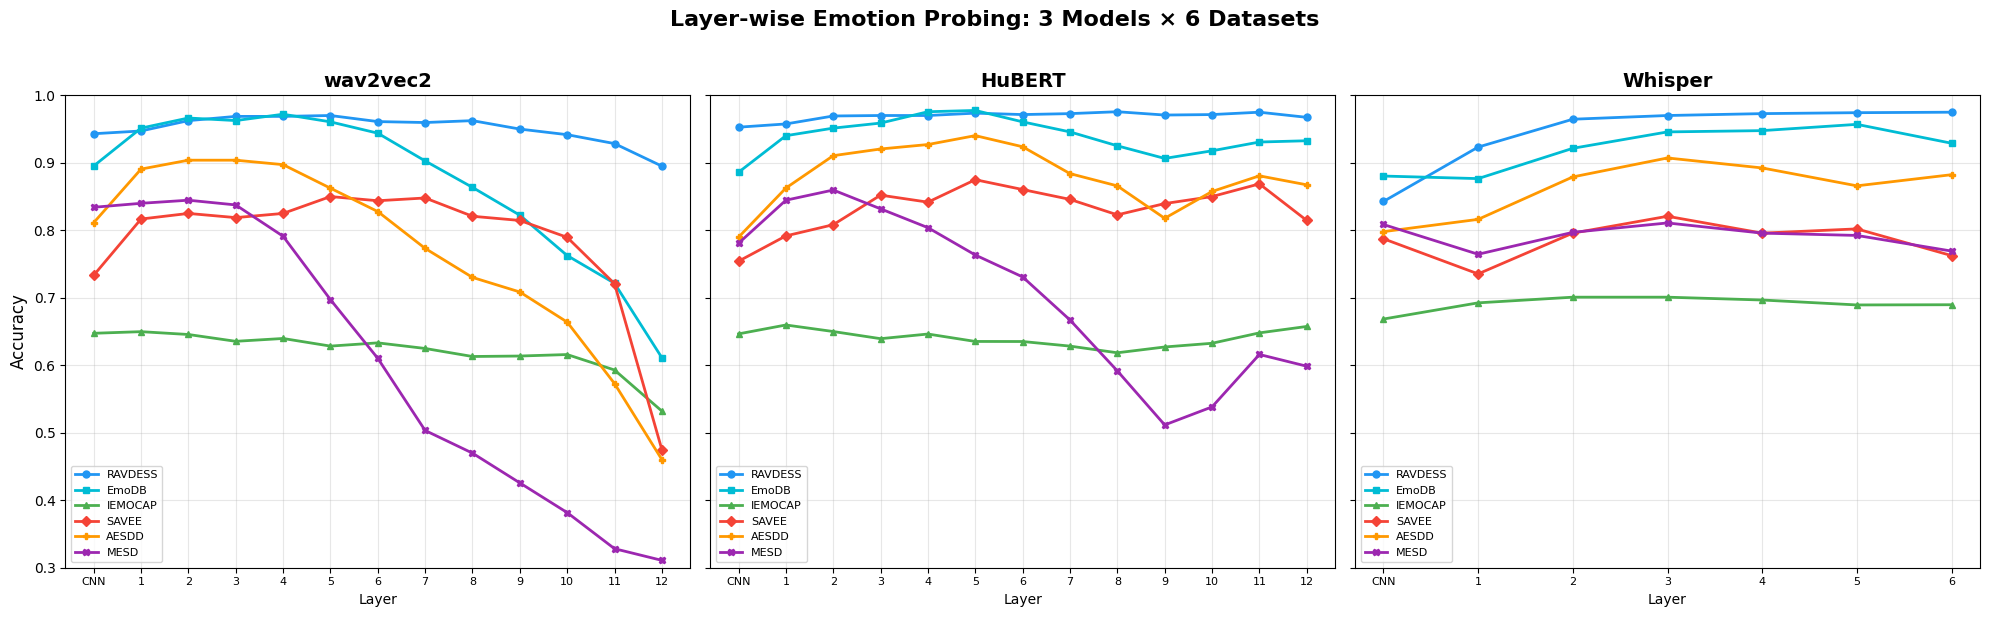

In [ ]:
dataset_colors = {
    'RAVDESS':'#2196F3','EmoDB':'#00BCD4','IEMOCAP':'#4CAF50',
    'SAVEE':'#F44336','AESDD':'#FF9800','MESD':'#9C27B0',
}
dataset_markers = {'RAVDESS':'o','EmoDB':'s','IEMOCAP':'^','SAVEE':'D','AESDD':'P','MESD':'X'}

# define number of layers per model
model_layer_counts = {
    'wav2vec2': 13,   # CNN + 12
    'HuBERT': 13,     # CNN + 12
    'Whisper': 7      # CNN + 6
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for ax, model in zip(axes, models_list):
    n_layers = model_layer_counts[model]
    x_layers = list(range(n_layers))

    # labels
    if n_layers == 13:
        layer_labels = ['CNN'] + [str(i) for i in range(1, 13)]
    elif n_layers == 7:
        layer_labels = ['CNN'] + [str(i) for i in range(1, 7)]
    else:
        layer_labels = [str(i) for i in range(n_layers)]

    for ds in datasets_list:
        key = f'{model} + {ds}'
        if key not in all_results:
            continue

        df = all_results[key]

        ax.plot(
            x_layers,
            df['Accuracy'].values,
            marker=dataset_markers[ds],
            linewidth=2,
            markersize=5,
            label=ds,
            color=dataset_colors[ds]
        )

    ax.set_title(model, fontsize=14, fontweight='bold')
    ax.set_xlabel('Layer')
    ax.set_xticks(x_layers)
    ax.set_xticklabels(layer_labels, fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0.3, 1.0])

axes[0].set_ylabel('Accuracy', fontsize=12)
plt.suptitle('Layer-wise Emotion Probing: 3 Models × 6 Datasets', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'all_18_3panel.png'), dpi=200, bbox_inches='tight')
plt.show()

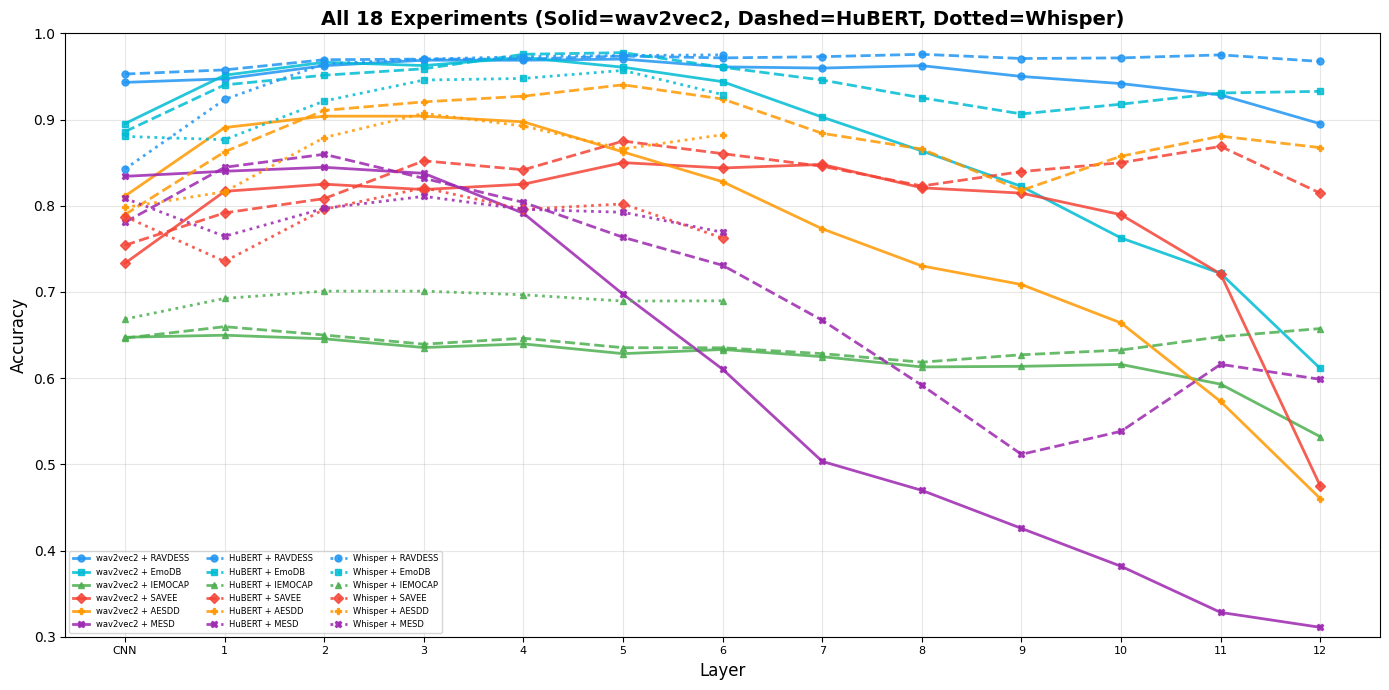

In [ ]:
dataset_colors = {
    'RAVDESS':'#2196F3','EmoDB':'#00BCD4','IEMOCAP':'#4CAF50',
    'SAVEE':'#F44336','AESDD':'#FF9800','MESD':'#9C27B0',
}
dataset_markers = {'RAVDESS':'o','EmoDB':'s','IEMOCAP':'^','SAVEE':'D','AESDD':'P','MESD':'X'}

# define number of layers per model
model_layer_counts = {
    'wav2vec2': 13,   # CNN + 12
    'HuBERT': 13,     # CNN + 12
    'Whisper': 7      # CNN + 6
}

linestyles = {
    'wav2vec2': '-',
    'HuBERT': '--',
    'Whisper': ':'
}

fig, ax = plt.subplots(figsize=(14, 7))

for model in models_list:
    n_layers = model_layer_counts[model]
    x_layers = list(range(n_layers))

    for ds in datasets_list:
        key = f'{model} + {ds}'
        if key not in all_results:
            continue

        df = all_results[key]

        ax.plot(
            x_layers,
            df['Accuracy'].values,
            marker=dataset_markers[ds],
            linestyle=linestyles[model],
            linewidth=2,
            markersize=5,
            color=dataset_colors[ds],
            alpha=0.85,
            label=key
        )

# full x-axis based on longest model
max_layers = max(model_layer_counts.values())
full_layer_labels = ['CNN'] + [str(i) for i in range(1, max_layers)]

ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title(
    'All 18 Experiments (Solid=wav2vec2, Dashed=HuBERT, Dotted=Whisper)',
    fontsize=14,
    fontweight='bold'
)
ax.set_xticks(range(max_layers))
ax.set_xticklabels(full_layer_labels, fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim([0.3, 1.0])
ax.legend(fontsize=6, ncol=3, loc='lower left')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'all_18_single.png'), dpi=200, bbox_inches='tight')
plt.show()

## Summary Table

In [ ]:
print('='*90)
print('SUMMARY: ALL 18 EXPERIMENTS')
print('='*90)
rows = []
for name, df in all_results.items():
    model, ds = name.split(' + ')
    best = df.loc[df['Accuracy'].idxmax()]
    rows.append({'Model':model,'Dataset':ds,'Best Layer':best['Layer'],
                 'Best Accuracy':best['Accuracy'],'Best F1':best['Weighted_F1']})
summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))
summary_df.to_csv(os.path.join(SAVE_DIR, 'summary_all_18.csv'), index=False)
print(f'\nSaved!')

SUMMARY: ALL 18 EXPERIMENTS
   Model Dataset Best Layer  Best Accuracy  Best F1
wav2vec2 RAVDESS    Layer 5         0.9701   0.9701
wav2vec2   EmoDB    Layer 4         0.9720   0.9719
wav2vec2 IEMOCAP    Layer 1         0.6498   0.6498
wav2vec2   SAVEE    Layer 5         0.8500   0.8473
wav2vec2   AESDD    Layer 2         0.9039   0.9035
wav2vec2    MESD    Layer 2         0.8446   0.8443
  HuBERT RAVDESS    Layer 8         0.9757   0.9757
  HuBERT   EmoDB    Layer 5         0.9776   0.9774
  HuBERT IEMOCAP    Layer 1         0.6597   0.6594
  HuBERT   SAVEE    Layer 5         0.8750   0.8722
  HuBERT   AESDD    Layer 5         0.9403   0.9399
  HuBERT    MESD    Layer 2         0.8597   0.8588
 Whisper RAVDESS    Layer 6         0.9750   0.9751
 Whisper   EmoDB    Layer 5         0.9570   0.9566
 Whisper IEMOCAP    Layer 2         0.7009   0.7009
 Whisper   SAVEE    Layer 3         0.8208   0.8183
 Whisper   AESDD    Layer 3         0.9072   0.9068
 Whisper    MESD    Layer 3         